In [213]:
from pathlib import Path

In [214]:
result_path = Path("../output_gpt-4o-mini_cochran")

In [215]:
import json

json_files = list(result_path.glob('**/RunnerResult_DefaultRefiner.json'))
data = []
for file in json_files:
    try:
        datapoint = json.load(open(file))
        data.append(datapoint)
    except Exception as e:
        print(file)

In [216]:
len(data)

227

In [217]:
success_ids = []

datapoint: dict
for datapoint in data:
    if "exploitSuccessResult" in datapoint:
        if datapoint["exploitSuccessResult"]:
            success_ids.append(datapoint["advisory"]["id"])
len(success_ids)

168

In [218]:
len(success_ids) / len(data) * 100, len(success_ids) / 227 * 100

(74.00881057268722, 74.00881057268722)

In [219]:
prompt_tokens = 0
completion_tokens = 0

datapoint: dict
for datapoint in data:
    if "model" in datapoint:
        model = datapoint["model"]
        totalPromptTokens = model["totalPromptTokens"]
        totalCompletionTokens = model["totalCompletionTokens"]
        prompt_tokens += totalPromptTokens
        completion_tokens += totalCompletionTokens

prompt_tokens, completion_tokens

(14921951, 4013473)

In [220]:
# GPT-4o-mini 
(prompt_tokens * 0.15 + completion_tokens * 0.6) / 1e6

4.646376449999999

In [221]:
# GPT-5.2
(prompt_tokens * 1.75 + completion_tokens * 14.00) / 1e6

82.30203625

In [222]:
for id in success_ids:
    print(id)

SNYK-JS-LOCALDEVICES-459898
SNYK-JS-INIREADER-1054843
npm:open:20180512
npm:11xiaoli:20170509
npm:git-dummy-commit:20180619
npm:asset-cache:20180226
SNYK-JS-JSONPOINTER-596925
GHSA-xrr6-6ww3-f3qm
npm:file-static-server:20180614
npm:dylmomo:20170518
SNYK-JS-JSONPOINTER-1577287
npm:dcdcdcdcdc:20170617
SNYK-JS-CONNIELANG-598853
npm:nodejsccc:20180315
SNYK-JS-UMOUNT-564265
SNYK-JS-TINYCONF-598792
SNYK-JS-TRIM-1017038
SNYK-JS-NODEEXTEND-571491
npm:mongo-parse:20160408
npm:api-proxy:20180226
npm:merge-objects:20180415
SNYK-JS-UIFABRICUTILITIES-571487
SNYK-JS-ONIONOLEDJS-1078808
npm:proxey:20180306
SNYK-JS-SAFEEVAL-608076
SNYK-JS-COLORSTRING-1082939
SNYK-JS-NORMALIZEURL-1296539
GHSA-54qm-37qr-w5wq
SNYK-JS-SUPERMIXER-607909
SNYK-JS-KEYGET-1048048
SNYK-JS-DEEPS-598667
SNYK-JS-CACHEDPATHRELATIVE-72573
npm:hdsdhhksjd:20180315
npm:serverwg:20170511
SNYK-JS-KEYD-674472
SNYK-JS-INIPARSERJS-1065989
SNYK-JS-MINIMIST-559764
SNYK-JS-GOOGLECLOUDSTORAGECOMMANDS-1050431
SNYK-JS-MIXINDEEP-450212
SNYK-JS-FIR

In [223]:
# Load the text file
with open('../dataset/SecBench.js.cochran', 'r') as f:
    ids = [line.strip() for line in f.readlines()]

In [224]:
len(ids)

227

In [225]:
def compare_lists(list_a, list_b):
    """
    Compare two lists and return common elements, unique to a, and unique to b.
    
    Args:
        list_a: First list
        list_b: Second list
    
    Returns:
        A tuple of (common, only_in_a, only_in_b)
    """
    set_a = set(list_a)
    set_b = set(list_b)
    
    common = list(set_a & set_b)
    only_in_a = list(set_a - set_b)
    only_in_b = list(set_b - set_a)
    
    return common, only_in_a, only_in_b

# Example usage with your existing lists
common, only_in_success_ids, only_in_ids = compare_lists(success_ids, ids)
print(f"Common: {len(common)}")
print(f"Only in success_ids: {len(only_in_success_ids)}")
print(f"Only in ids: {len(only_in_ids)}")

Common: 168
Only in success_ids: 0
Only in ids: 59


In [226]:
for id in only_in_ids:
    print(id)

SNYK-JS-MOSC-571492
SNYK-JS-HTMLPARSESTRINGIFY-1079306
SNYK-JS-DECAL-1051028
SNYK-JS-OBJECTPATH-1569453
SNYK-JS-OBJTOOLS-674471
SNYK-JS-NEDB-1305279
npm:ptest:20180226
npm:simple-mock-server:20180226
SNYK-JS-KILLPROCESSBYNAME-1078534
SNYK-JS-MOOTOOLS-1325536
SNYK-JS-ASSIGNDEEP-450211
npm:zhaolei1111:20180315
npm:parsejson:20170908
SNYK-JS-SERVEHEREJS-450884
npm:dilu:20180226
npm:slug:20170907
npm:httpea:20180226
npm:serverhuwenhui:20170516
SNYK-JS-KILLPORT-1078535
SNYK-JS-MARKDOWNIT-2331914
SNYK-JS-HTMLPARSESTRINGIFY2-1079307
npm:nitro-server:20180226
SNYK-JS-LIBNMAP-72551
SNYK-JS-FASTCSV-1049538
SNYK-JS-REALMSSHIM-2309907
SNYK-JS-SERIALIZEJAVASCRIPT-570062
npm:node-htmlparser-classic:20170906
SNYK-JS-TERMINALKIT-1734787
SNYK-JS-FASTJSONPATCH-595663
SNYK-JS-ETHERS-1586048
npm:node-http-server:20180226
npm:run-this-place:20170508
npm:moment:20170905
SNYK-JS-NCONFTOML-1296831
SNYK-JS-REMARKABLE-174639
SNYK-JS-TRIMOFFNEWLINES-1296850
SNYK-JS-HTTPFILESERVER-451564
SNYK-JS-COMPONENTFLATTEN-

In [227]:
result_map = {
    "path-traversal": {"success": [], "failed": [], "new": []},
    "redos": {"success": [], "failed": [], "new": []},
    "command-injection": {"success": [], "failed": [], "new": []},
    "code-injection": {"success": [], "failed": [], "new": []},
    "prototype-pollution": {"success": [], "failed": [], "new": []},
}

num_error = 0

datapoint: dict
for datapoint in data:
    if "error" in datapoint:
        if datapoint["error"]:
            num_error += 1
            continue
    llmIdentifiedVulnerabilityTypes = datapoint["llmIdentifiedVulnerabilityTypes"]
    # if len(llmIdentifiedVulnerabilityTypes) > 1:
    #     print(llmIdentifiedVulnerabilityTypes)
    #     break
    label = llmIdentifiedVulnerabilityTypes[0]["label"]
    id = datapoint["advisory"]["id"]
    if "exploitSuccessResult" in datapoint and datapoint["exploitSuccessResult"]:
        result_map[label]["success"].append(id)
    else:
        result_map[label]["failed"].append(id)

print("num_error: ", num_error)

num_error:  19


In [228]:
new_exp_result_path = Path("../output")
new_json_files = list(new_exp_result_path.glob('**/RunnerResult_DefaultRefiner.json'))
new_data = []
for file in new_json_files:
    try:
        datapoint = json.load(open(file))
        new_data.append(datapoint)
    except Exception as e:
        print(file)

num_error = 0

# Process new data and update result_map
for datapoint in new_data:
    if "error" in datapoint:
        if datapoint["error"]:
            num_error += 1
            continue
    llmIdentifiedVulnerabilityTypes = datapoint["llmIdentifiedVulnerabilityTypes"]
    label = llmIdentifiedVulnerabilityTypes[0]["label"]
    id = datapoint["advisory"]["id"]
    if "exploitSuccessResult" in datapoint and datapoint["exploitSuccessResult"]:
        result_map[label]["new"].append(id)
        if id in result_map[label]["failed"]:
            result_map[label]["failed"].remove(id)
print("num_error: ", num_error)

num_error:  1


In [229]:
# Convert each list in result_map to its length
for v_type, data in result_map.items():
    for key in ["success", "failed", "new"]:
        data[key] = len(list(set(data[key])))

print("✅ Converted result_map (lists replaced with their lengths):")
result_map

✅ Converted result_map (lists replaced with their lengths):


{'path-traversal': {'success': 53, 'failed': 1, 'new': 1},
 'redos': {'success': 13, 'failed': 16, 'new': 4},
 'command-injection': {'success': 32, 'failed': 3, 'new': 1},
 'code-injection': {'success': 12, 'failed': 4, 'new': 0},
 'prototype-pollution': {'success': 58, 'failed': 9, 'new': 4}}

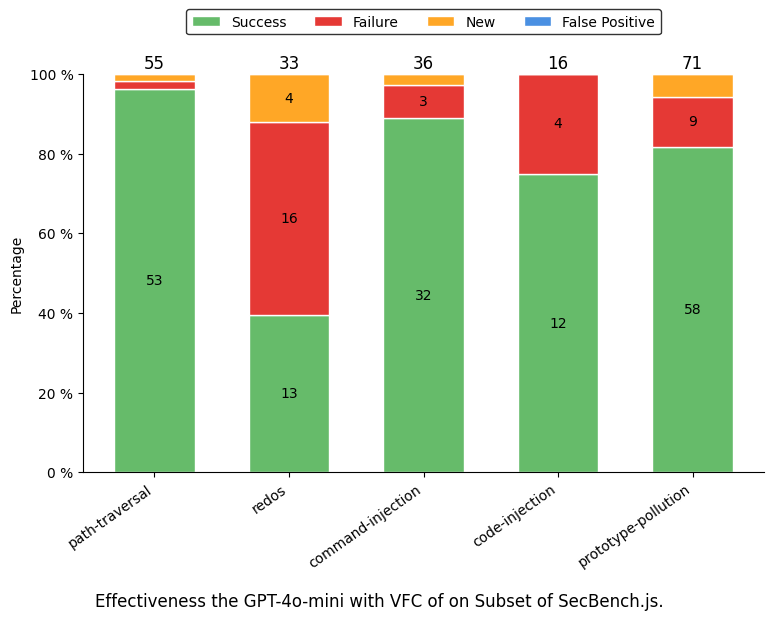

In [ ]:
# Stacked percentage bar chart replicating the provided figure
import numpy as np
import matplotlib.pyplot as plt

# Data
categories = list(result_map.keys())
# Raw counts for each outcome per category
success = np.array([result["success"] for result in result_map.values()])
failure = np.array([result["failed"] for result in result_map.values()])
new = np.array([result["new"] for result in result_map.values()])
false_positive = np.array([0, 0, 0, 0, 0])

# Derived values
totals = success + failure + new + false_positive
success_pct = success / totals * 100.0
failure_pct = failure / totals * 100.0
new_pct = new / totals * 100.0
fp_pct = false_positive / totals * 100.0

x = np.arange(len(categories))
bar_width = 0.6

colors = {
    "Success": "#66bb6a",      # green
    "Failure": "#e53935",      # red
    "New": "#ffa726",          # orange
    "False Positive": "#4a90e2",  # blue
}

fig, ax = plt.subplots(figsize=(8, 7))

# Stacked bars
bars_success = ax.bar(
    x, success_pct, bar_width, label="Success", color=colors["Success"], edgecolor="white"
)
bars_failure = ax.bar(
    x,
    failure_pct,
    bar_width,
    bottom=success_pct,
    label="Failure",
    color=colors["Failure"],
    edgecolor="white",
)
bars_new = ax.bar(
    x,
    new_pct,
    bar_width,
    bottom=success_pct + failure_pct,
    label="New",
    color=colors["New"],
    edgecolor="white",
)
bars_fp = ax.bar(
    x,
    fp_pct,
    bar_width,
    bottom=success_pct + failure_pct + new_pct,
    label="False Positive",
    color=colors["False Positive"],
    edgecolor="white",
)

# Helper to annotate count labels inside each segment (hide if segment is tiny)
def annotate_segment_counts(bars, counts, bottoms):
    for rect, count, bottom in zip(bars, counts, bottoms):
        height = rect.get_height()
        if height < 6:  # skip very small segments to avoid clutter
            continue
        ax.text(
            rect.get_x() + rect.get_width() / 2.0,
            bottom + height / 2.0,
            f"{int(count)}",
            ha="center",
            va="center",
            fontsize=10,
            color="black",
        )

annotate_segment_counts(bars_success, success, np.zeros_like(success_pct))
annotate_segment_counts(bars_failure, failure, success_pct)
annotate_segment_counts(bars_new, new, success_pct + failure_pct)
annotate_segment_counts(bars_fp, false_positive, success_pct + failure_pct + new_pct)

# Totals above bars
ax.set_ylim(0, 100)
for xi, total in zip(x, totals):
    ax.text(xi, 100.5, f"{int(total)}", ha="center", va="bottom", fontsize=12, clip_on=False)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.set_ylabel("Percentage")
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([f"{v} %" for v in np.arange(0, 101, 20)])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend on top
legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=4,
    frameon=True,
)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")

# Caption below the chart
plt.figtext(
    0.5,
    0.01,
    "Effectiveness the GPT-4o-mini with VFC of on Subset of SecBench.js.",
    ha="center",
    fontsize=12,
)

plt.tight_layout(rect=[0.02, 0.04, 1, 0.92])
plt.savefig("av2.3.sec.png", dpi=300, bbox_inches="tight")
plt.show()
